# Brain Tumor Classification

Without dataset merge (training + testing) before preprocessing.

Hence,

`Acquire -> Split (Train & Test) -> Preprocess -> Split (Train & Val) -> Extract`


## Library Imports


In [82]:
import os
from glob import glob
from zipfile import ZipFile

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

## Dataset Acquisition


### Import

In [83]:
data_path = "./data/"
dataset_file = data_path + "brain-sartaj.zip"

zip = ZipFile(dataset_file)
zip.extractall(data_path)
zip.close()

print(os.listdir(data_path))

['brain-sartaj.zip', 'Testing', 'Training']


### Train Test Split

In [84]:
train_path = os.path.join(data_path, "Training")
test_path = os.path.join(data_path, "Testing")

classes = os.listdir(train_path)

print(classes)

['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


## Preprocessing

In [ ]:
def preprocess(datapath, label, X, y, idx):
    images = glob(os.path.join(datapath, label, "*.jpg"))

    for img in images:
        img_raw = cv.imread(img)

        # Preprocess: Image Resizing
        img_resized = cv.resize(img_raw, (128, 128))

        # Preprocess: Image Grayscaling
        img_grayscaled = cv.cvtColor(img_resized, cv.COLOR_BGR2GRAY)

        # Preprocess: Image Normalizing
        img_normalized = img_grayscaled / 255
        
        X.append(img_normalized)
        y.append(idx)

In [ ]:
X, img = [], []
X_test, y_test = [], []

for idx, label in enumerate(classes):
    preprocess(train_path, label, X, img, idx)
    preprocess(test_path, label, X_test, y_test, idx)

print(len(X), len(img))
print(len(X_test), len(y_test))

2870 2870
394 394


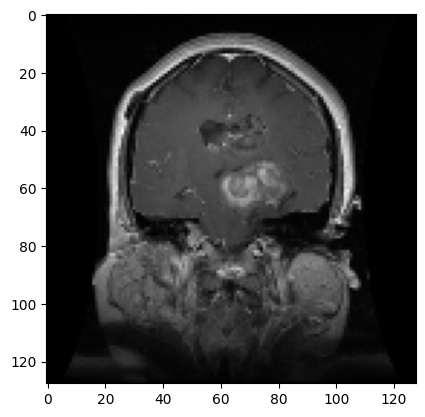

In [87]:
plt.imshow(X[0], cmap="gray")

### Data Splitting


In [ ]:

X_train, X_val, y_train, y_val = train_test_split(
    X, img, 
    test_size=0.2,
    random_state=42)

X_train[:5]

[array([[0.02745098, 0.04705882, 0.04705882, ..., 0.00392157, 0.        ,
         0.00392157],
        [0.03137255, 0.05490196, 0.05490196, ..., 0.00392157, 0.        ,
         0.00784314],
        [0.01568627, 0.04313725, 0.04313725, ..., 0.00392157, 0.        ,
         0.00784314],
        ...,
        [0.02352941, 0.05098039, 0.0627451 , ..., 0.00784314, 0.00392157,
         0.00392157],
        [0.01568627, 0.05098039, 0.06666667, ..., 0.00392157, 0.00392157,
         0.00392157],
        [0.00392157, 0.01176471, 0.01960784, ..., 0.00392157, 0.        ,
         0.        ]], shape=(128, 128)),
 array([[0.01176471, 0.01176471, 0.01176471, ..., 0.00784314, 0.00784314,
         0.00392157],
        [0.01176471, 0.01176471, 0.01176471, ..., 0.00784314, 0.00784314,
         0.00392157],
        [0.01176471, 0.01176471, 0.01176471, ..., 0.00784314, 0.00784314,
         0.00784314],
        ...,
        [0.00784314, 0.00784314, 0.00784314, ..., 0.00784314, 0.00784314,
         0.00784

## Feature Extraction

In [ ]:
# Convert pixel's binary to decimal representation
def convert_bin_to_dec(bin):
    pows = [128, 64, 32, 16, 8, 4, 2, 1]
    dec = 0

    # Assign each binary digit to its decimal weight
    for bin_idx in range(len(bin)):
        dec += bin[bin_idx] * pows[bin_idx]

    return dec

### Local Binary Pattern (Classic)

In [ ]:
def lbp(img):
    height, width = img.shape
    img_lbp = np.zeros((height, width), np.uint8)

    for i in range(height):
        for j in range(width):
            c = img[i, j]

            # Neighboring pixels' coordinates from the center
            p_coords = [(i-1, j-1), (i-1, j), (i-1, j+1), # top (pixel positions from the center)
                        (i, j+1),                         # right
                        (i+1, j+1), (i+1, j), (i+1, j-1), # bottom
                        (i, j-1)]                         # left
            
            # Each center pixel's binary representation from classic LBP
            c_lbp_bin = []

            for p_coord in p_coords:
                # Handle overflowed neighboring pixels outside the image
                try:
                    # Find the intensity value of the neighboring pixels
                    # Assign 0 for negative pixel indices (above & left of the image)
                    p = img[p_coord[0], p_coord[1]] if(p_coord[0] >= 0 and p_coord[1] >= 0) else 0
                except:
                    # Out of range pixel indices (below & right of the image)
                    p = 0

                # Threshold and append binary value to pixel representation
                p_lbp_bin_dig = 1 if(p > c) else 0
                c_lbp_bin.append(p_lbp_bin_dig)

            # Assign each pixels' decimal representation value to feature vector
            img_lbp[i][j] = convert_bin_to_dec(c_lbp_bin)

    return img_lbp

### nLBP


In [ ]:
def nlbp(img, distance):
    height, width = img.shape
    img_nlbp = np.zeros((height, width), np.uint8)
    
    for i in range(height):
        for j in range(width):
            # Neighboring pixels' coordinates from the center
            p_coords = [(i-1, j-1), (i-1, j), (i-1, j+1), # top (pixel positions from the center)
                        (  i, j+1),                       # right
                        (i+1, j+1), (i+1, j), (i+1, j-1), # bottom
                        (  i, j-1)]                       # left
            
            # Each center pixel's binary representation from nLBP
            c_nlbp_bin = []

            for p_coord_idx in range(len(p_coords)):
                # Coordinates of the two neighboring pixels based on the chosen d parameter
                p_a_idx = p_coord_idx
                p_b_idx = (p_coord_idx + distance) % 8

                # Handle overflowed neighboring pixels outside the image
                try:
                    # Find the intensity value of the neighboring pixels
                    # Assign 0 for outer edge of the first neighboring pixel (above & left)
                    p_a_bin_dig = 0 if(-1 in p_coords[p_a_idx]) else img[p_coords[p_a_idx]]
                except:
                    # Out of range pixel indices (below & right)
                    p_a_bin_dig = 0
                
                try:
                    # Find the intensity value of the neighboring pixels
                    # Assign 0 for outer edge of the second neighboring pixel (above & left)
                    p_b_bin_dig = 0 if(-1 in p_coords[p_b_idx]) else img[p_coords[p_b_idx]]
                except:
                    # Out of range pixel indices (below & right)
                    p_b_bin_dig = 0

                # Threshold and append binary value to pixel representation
                p_nlbp_bin_val = 1 if(p_a_bin_dig > p_b_bin_dig) else 0
                c_nlbp_bin.append(p_nlbp_bin_val)

            # Assign each pixels' decimal representation value to feature vector
            img_nlbp[i][j] = convert_bin_to_dec(c_nlbp_bin)

    return img_nlbp

### αLBP


In [169]:
def albp(img, alpha):
    height, width = img.shape
    img_albp = np.zeros((height, width), np.uint8)

    # Neighboring pixel's coordinate candidates based on the chosen alpha parameter
    p_crds_list = {
        0  : [( 0, 4), ( 0, 3), ( 0, 2), ( 0, 1), ( 0,-1), ( 0,-2), ( 0,-3), ( 0,-4)],
        45 : [(-4, 4), (-3, 3), (-2, 2), (-1, 1), ( 1,-1), ( 2,-2), ( 3,-3), ( 4,-4)],
        90 : [( 4, 0), ( 3, 0), ( 2, 0), ( 1, 0), (-1, 0), (-2, 0), (-3, 0), (-4, 0)],
        135: [(-4,-4), (-3,-3), (-2,-2), (-1,-1), ( 1, 1), ( 2, 2), ( 3, 3), ( 4, 4)],
    }

    for i in range(height):
        for j in range(width):
            c = img[i][j] 
            
            # Handle alpha parameter input outside scope
            if(alpha % 360 not in p_crds_list):
                return print("Incorrect alpha parameter value")
            
            # Chosen neighboring pixels based on the alpha parameter
            p_crds = p_crds_list[alpha]

            # Each pixel's binary representation from αLBP
            c_albp_bin = []

            for p in p_crds:
                # Handle overflowed neighboring pixels outside the image
                try:
                    # Coordinates of the neighboring pixels based on their center
                    i_crd = i + p[0]
                    j_crd = j + p[1]

                    # Find neighboring pixel of a center pixel
                    # Assign 0 for negative pixel indices (above & left of the image)
                    p = img[i_crd, j_crd] if (i_crd >= 0 and j_crd >= 0) else 0 
                except:
                    # Out of range pixel indices (below & right)
                    p = 0

                # Threshold and append binary value to pixel representation
                p_albp_bin_dig = 1 if p > c else 0
                c_albp_bin.append(p_albp_bin_dig)

            # Assign each pixels' decimal representation value to feature vector
            img_albp[i, j] = convert_bin_to_dec(c_albp_bin)

    return img_albp

In [ ]:
# TESTS

# dum = [[0, 1, 2],
#        [3, 4, 5],
#        [6, 7, 8]]

dum = [[ 0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
       [10,11,12,13,14,15,16,17,18,19],
       [20,21,22,23,24,25,26,27,28,29],
       [30,31,32,33,34,35,36,37,38,39],
       [40,41,42,43,44,45,46,47,48,49],
       [50,51,52,53,54,55,56,57,58,59],
       [60,61,62,63,64,65,66,67,68,69],
       [70,71,72,73,74,75,76,77,78,79],
       [80,81,82,83,84,85,86,87,88,89],
       [90,91,92,93,94,95,96,97,98,99]]

dum_lbp = lbp(np.array(dum))
dum_nlbp = nlbp(np.array(dum), 2)
dum_albp = albp(np.array(dum), 135)

print("LBP", "\n", dum_lbp)
print("nLBP", "\n", dum_nlbp)
print("aLBP", "\n", dum_albp)

LBP 
 [[28 30 30 30 30 30 30 30 30  6]
 [28 30 30 30 30 30 30 30 30  6]
 [28 30 30 30 30 30 30 30 30  6]
 [28 30 30 30 30 30 30 30 30  6]
 [28 30 30 30 30 30 30 30 30  6]
 [28 30 30 30 30 30 30 30 30  6]
 [28 30 30 30 30 30 30 30 30  6]
 [28 30 30 30 30 30 30 30 30  6]
 [28 30 30 30 30 30 30 30 30  6]
 [16 16 16 16 16 16 16 16 16  0]]
nLBP 
 [[ 12  14  15  15  15  15  15  15  15   7]
 [ 12  15  15  15  15  15  15  15  15 199]
 [ 12  15  15  15  15  15  15  15  15 199]
 [ 12  15  15  15  15  15  15  15  15 199]
 [ 12  15  15  15  15  15  15  15  15 199]
 [ 12  15  15  15  15  15  15  15  15 199]
 [ 12  15  15  15  15  15  15  15  15 199]
 [ 12  15  15  15  15  15  15  15  15 199]
 [ 12  15  15  15  15  15  15  15  15 199]
 [ 48  49  49  49  49  49  49  49  49 193]]
aLBP 
 [[15 15 15 15 15 15 14 12  8  0]
 [15 15 15 15 15 15 14 12  8  0]
 [15 15 15 15 15 15 14 12  8  0]
 [15 15 15 15 15 15 14 12  8  0]
 [15 15 15 15 15 15 14 12  8  0]
 [15 15 15 15 15 15 14 12  8  0]
 [14 14 14 14 14 14 

In [ ]:
# TODO: MB-LBP
# TODO: histogram representation

## Classification

### Support Vector Machine


In [92]:
classifier = SVC()
classifier.fit(X_train, y_train)

classifier.predict(X_test[1])

ValueError: Found array with dim 3, while dim <= 2 is required by SVC.